# Layer 2 — From Frozen CSVs to a Demo-Ready Checkpoint

This notebook dissects **one artifact**: `stgnn_final.pt`, the trained STGNN that the demo will load.

The goal is not to produce new numbers. It is to make every step **visible**: what is read from disk, what shape the tensors are, what the model actually sees, what goes into the checkpoint, and how to prove that checkpoint genuinely reloads.

---

## What this notebook DOES

| | |
|---|---|
| §1–§4 | Walk the data: frozen CSVs → feature tensor → graph → forecasting task |
| §5 | Run `train_final.py` (the real script, not a copy) |
| §6 | Dissect `stgnn_final.pt` field by field |
| §7 | Reload from scratch and run one forward pass, step by step |
| §8 | Look at the scores: distribution + position on the plantation lattice |
| §9 | Run `verify_checkpoint.py` (the formal check, separate process) |

## What this notebook does NOT do

- It produces **no performance number**. The model here is trained on all 1,200 palms with **no held-out set**. Every quotable AUC-PR comes from `run_real.py` / `run_v2.py`, which use leave-one-parcel-out.
- It does **not** redefine the architecture. It imports `models_real.py` and `run_real.py` as they are.
- It does **not** touch the validated decomposition code.

> ⚠️ **The warning attached to this artifact**
>
> `stgnn_final.pt` is an **inference** artifact, not an **evaluation** artifact. Every palm it scores is a palm it saw during training. Its output is a **relative score for ranking**, not a calibrated probability — never present `sigmoid(logit)` as a "% chance of infection". This warning is also stored inside the `.pt` file as the `scope_warning` field, so it cannot be lost when the file changes hands.

**Prerequisite:** the working directory should be `layer2_real/`. Every other path is anchored to the module file, not to the cwd.

## §0 — Setup

The only thing that matters here: `HERE` must point at `layer2_real/`, because `dataset.py` anchors its CSV paths relative to its own module location.

---

> ### If the cell below fails with `ModuleNotFoundError: No module named 'numpy'`
>
> That is **not** a problem with the notebook — the kernel your editor selected points at a different Python interpreter.
>
> This notebook needs the **`Python 3.11 (SawitGuard)`** kernel, which is pinned to `C:\Program Files\Python311\python.exe` — the only interpreter on this machine that has `numpy`, `torch`, `pandas`, `scikit-learn` and `scipy`.
>
> **VS Code:** kernel picker (top right) → *Select Another Kernel* → *Jupyter Kernel* → **Python 3.11 (SawitGuard)**.
>
> **JupyterLab:** *Kernel* menu → *Change Kernel* → **Python 3.11 (SawitGuard)**.
>
> Avoid the default `Python 3 (ipykernel)` kernel: its interpreter is recorded as `python` (a relative command, not an absolute path), so it resolves to whichever Python happens to come first on the launching process's `PATH` — and in an editor, that is the wrong one.
>
> The first cell prints `sys.executable`; if it is not `C:\Program Files\Python311\python.exe`, the kernel is still wrong.

In [22]:
import os, sys, json, subprocess, hashlib
import numpy as np
import torch

# Anchor to layer2_real/ regardless of the notebook's cwd.
HERE = os.path.abspath("." if os.path.basename(os.getcwd()) == "layer2_real"
                       else os.path.join(".", "layer2_real"))
assert os.path.exists(os.path.join(HERE, "dataset.py")), f"not the layer2_real folder: {HERE}"
if HERE not in sys.path:
    sys.path.insert(0, HERE)

import dataset as ds
import models_real as M

print("interpreter :", sys.executable)
print("folder      :", HERE)
print("torch       :", torch.__version__)
print("numpy       :", np.__version__)
print("dataset.py  : WINDOW=%d  HORIZONS=%s  N_REL=%d" % (ds.WINDOW, ds.HORIZONS, ds.N_REL))
print("models_real : HIDDEN=%d  N_REL=%d" % (M.HIDDEN, M.N_REL))

interpreter : c:\Program Files\Python311\python.exe
folder      : c:\Users\Rifqi\Documents\Datathon\oil-palm-detection-datathon-2026\layer2_real
torch       : 2.13.0+cpu
numpy       : 1.26.4
dataset.py  : WINDOW=3  HORIZONS=(1, 2, 3, 4)  N_REL=1
models_real : HIDDEN=34  N_REL=1


## §1 — Frozen data: three CSVs, and only three

`dataset.py` **never** reads the raw `Eg9PP_Phenotypes.csv`. It reads only the three CSVs already frozen by `data_clean/build_layer2_real.py`:

```
Eg9PP_Phenotypes.csv
   └─ build_layer2_real.py   x·cos30° correction · KD-tree r=1.5 · A/S/D/C panel
        └─ layer2_nodes.csv    1,200 rows — palm, genotype, coordinates, fold
           layer2_panel.csv    54,000 rows — palm × census (long format)
           layer2_edges.csv    3,354 rows — edge list
```

The split is deliberate: the builder carries **assertions** that halt the process if any number shifts, so every downstream script may assume the data is correct without re-checking it.

In [23]:
nodes, panel, edges = ds.load()

print("nodes :", nodes.shape, "->", list(nodes.columns))
print("panel :", panel.shape, "->", list(panel.columns))
print("edges :", edges.shape, "->", list(edges.columns))

print("\n--- first 3 rows of nodes ---")
display(nodes.head(3))

print("--- first palm's status across the first 8 censuses ---")
display(panel[panel.palm_id == nodes.palm_id.iloc[0]].head(8)[
    ["palm_id", "t", "status", "at_risk", "n_nb_sympt", "n_nb_dead"]])

nodes : (1200, 13) -> ['palm_id', 'progeny', 'ga_parent', 'gb_parent', 'parcel', 'plot', 'xm', 'ym', 'event_t1s', 'y_t1s', 'event_td', 'y_td', 'fold']
panel : (54000, 9) -> ['palm_id', 't', 'status', 'at_risk', 'deg', 'n_nb_obs', 'n_nb_sympt', 'n_nb_dead', 'prev_global']
edges : (3354, 3) -> ['a', 'b', 'parcel']

--- first 3 rows of nodes ---


,palm_id,progeny,ga_parent,gb_parent,parcel,plot,xm,ym,event_t1s,y_t1s,event_td,y_td,fold
0,D1L3_1,D1L3,D1,L3,44A,68,7.794229,3.5,1,25.5,0,25.5,44A
1,D1L3_2,D1L3,D1,L3,44A,68,7.794229,4.5,1,7.5,1,8.5,44A
2,D1L3_3,D1L3,D1,L3,44A,68,7.794229,5.5,1,8.0,1,8.5,44A


--- first palm's status across the first 8 censuses ---


,palm_id,t,status,at_risk,n_nb_sympt,n_nb_dead
0,D1L3_1,0.5,A,1,0,0
1200,D1L3_1,1.5,A,1,0,0
2400,D1L3_1,2.5,A,1,0,0
3600,D1L3_1,3.5,A,1,0,0
4800,D1L3_1,4.0,A,1,0,0
6000,D1L3_1,4.5,A,1,0,0
7200,D1L3_1,5.0,A,1,0,0
8400,D1L3_1,6.0,A,1,0,0


In [24]:
cen = ds.census()
T, N = ds.shape()
print(f"censuses : {T} dates, from t={cen.min():.1f} yr to t={cen.max():.1f} yr")
print(f"palms    : {N}")
print(f"\ncensus spacing is NOT regular — unique dt: {sorted(set(np.round(np.diff(cen), 3)))}")
print("this is why the horizon h is counted in CENSUS STEPS, not years.")

st = ds.status_matrix()
print(f"\nstatus matrix {st.shape} — unique values {sorted(set(st.ravel().tolist()))}")
print("  A = asymptomatic (in the risk set)")
print("  S = symptomatic  |  D = dead  |  C = censored (LEAVES the risk set, NOT healthy)")

import collections
for k in (0, 10, 22, 44):
    c = collections.Counter(st[k])
    print(f"  census idx {k:2d} (t={cen[k]:5.1f} yr): " +
          "  ".join(f"{s}={c.get(s,0):4d}" for s in "ASDC"))

censuses : 45 dates, from t=0.5 yr to t=25.5 yr
palms    : 1200

census spacing is NOT regular — unique dt: [0.5, 1.0]
this is why the horizon h is counted in CENSUS STEPS, not years.

status matrix (45, 1200) — unique values ['A', 'C', 'D', 'S']
  A = asymptomatic (in the risk set)
  S = symptomatic  |  D = dead  |  C = censored (LEAVES the risk set, NOT healthy)
  census idx  0 (t=  0.5 yr): A=1199  S=   1  D=   0  C=   0
  census idx 10 (t=  7.5 yr): A=1164  S=   9  D=  14  C=  13
  census idx 22 (t= 14.0 yr): A=1047  S=  42  D=  78  C=  33
  census idx 44 (t= 25.5 yr): A=   0  S= 335  D= 366  C= 499


## §2 — The feature tensor: three blocks, and why one of them is always zero

Eg9PP has **no imagery and no spectra**. The only per-palm per-census signal is the palm's own status — and inside the risk set that status is **always `A`**. So a palm's own status history is *degenerate*: zero information.

The feature matrix is therefore split into three blocks:

| Block | Columns | Contents | At the query node |
|---|---|---|---|
| **SELF** | 4 | time/age: `t_years`, `census_idx`, `dt_prev`, `log1p_t` | identical for every palm at the same census |
| **GENO** | 14 | one-hot `progeny` — a **mandatory** covariate (prohibition #5) | static |
| **STATE** | 6 | `is_sympt`, `is_dead`, `is_cens` + backward differences | **constant 0** |

The STATE block exists **not** for the query node — there it is zero. It exists purely as **diffusion payload**: because `D = A @ F`, a neighbour that is symptomatic or dead shows up in `D_seq`. Without this block the graph would carry no epidemic signal at all.

This is the mechanism that keeps prohibition #1 satisfied: what a palm sees about **itself** is a constant; the only informative content arrives from its **neighbours**.

In [25]:
F = np.asarray(ds.node_features(np.arange(T)), np.float32)   # scaler is fit here
names = ds.feature_names()

print(f"feature tensor F : {F.shape}   (T censuses, N palms, d features)")
print(f"column count     : {len(names)}\n")
for lbl, sl in (("SELF ", ds.SELF_SLICE), ("GENO ", ds.GENO_SLICE), ("STATE", ds.STATE_SLICE)):
    print(f"  {lbl} cols {sl.start:2d}..{sl.stop-1:2d} : {names[sl]}")

feature tensor F : (45, 1200, 24)   (T censuses, N palms, d features)
column count     : 24

  SELF  cols  0.. 3 : ['t_years', 'census_idx', 'dt_prev', 'log1p_t']
  GENO  cols  4..17 : ['geno=D1L3', 'geno=D1Y1', 'geno=D2L1', 'geno=D2L2', 'geno=D2L3', 'geno=D2Y1', 'geno=D3L1', 'geno=D3L2', 'geno=D3L3', 'geno=D3Y1', 'geno=D4L1', 'geno=D4L3', 'geno=D5L2', 'geno=D5L3']
  STATE cols 18..23 : ['is_sympt', 'is_dead', 'is_cens', 'd_sympt', 'd_dead', 'd_cens']


In [26]:
# Proof the STATE block really is zero on the risk set (this is what test_dataset.py::G2 asserts).
tree, t_idx, y = ds.build_examples(3, np.arange(T))
state_at_query = F[t_idx, tree][:, ds.STATE_SLICE]

print("STATE block across ALL h=3 query examples:")
print(f"  shape          : {state_at_query.shape}")
print(f"  max |value|    : {np.abs(state_at_query).max():.1f}   <- must be 0.0")
print(f"  all exactly 0  : {bool((state_at_query == 0).all())}")

print("\nCompare the same block AFTER diffusion (i.e. the neighbours' values):")
A = np.asarray(ds.adjacency("true"), np.float32)
D = ds.diffuse(F, A)
state_diffused = D[t_idx, tree, 0][:, ds.STATE_SLICE]
print(f"  max |value|    : {np.abs(state_diffused).max():.4f}   <- NOT zero")
print(f"  mean           : {state_diffused.mean():.4f}")
print("\n-> the epidemic signal enters THROUGH THE GRAPH, not through the palm itself.")

STATE block across ALL h=3 query examples:
  shape          : (40828, 6)
  max |value|    : 0.0   <- must be 0.0
  all exactly 0  : True

Compare the same block AFTER diffusion (i.e. the neighbours' values):
  max |value|    : 1.0733   <- NOT zero
  mean           : 0.0315

-> the epidemic signal enters THROUGH THE GRAPH, not through the palm itself.


## §3 — The proximity graph

An edge exists when the inter-palm distance is ≤ **1.5 × planting spacing**. Two numbers must match, and both are gates inside `build_layer2_real.py`:

- **3,354 edges**
- **mean degree 5.59**

If the degree came out ≈ 8, the `x · cos30°` correction did not apply and the lattice is being read as square rather than triangular — and everything downstream would be built on the wrong graph.

One more property makes *leave-one-parcel-out* legitimate: **0 of the 3,354 edges cross a parcel boundary**.

In [27]:
print(f"adjacency A      : {A.shape}  dtype {A.dtype}")
print(f"symmetric        : {np.allclose(A, A.T)}")
print(f"zero diagonal    : {np.allclose(np.diag(A), 0)}")
print(f"edge count       : {int(A.sum() // 2)}      <- expected 3354")
print(f"mean degree      : {A.sum(1).mean():.2f}    <- expected 5.59 (triangular lattice)")
print(f"degree min/max   : {int(A.sum(1).min())} / {int(A.sum(1).max())}")

parcel_of = nodes.set_index('palm_id').parcel
cross = int((parcel_of[edges.a].to_numpy() != parcel_of[edges.b].to_numpy()).sum())
print(f"\ncross-parcel edges : {cross}  <- must be 0; this is what makes fold=parcel valid")

# Edge lengths: at r=1.5 on a triangular lattice, ONLY the first shell is reachable.
pos = nodes.set_index("palm_id")[["xm", "ym"]]
L = np.hypot(*(pos.loc[edges.a].to_numpy() - pos.loc[edges.b].to_numpy()).T)
print(f"edge length      : min {L.min():.3f}  median {np.median(L):.3f}  max {L.max():.3f}")
print("-> every edge has length 1.000: the six immediate neighbours, nothing further.")

adjacency A      : (1200, 1200)  dtype float32
symmetric        : True
zero diagonal    : True
edge count       : 3354      <- expected 3354
mean degree      : 5.59    <- expected 5.59 (triangular lattice)
degree min/max   : 2 / 6

cross-parcel edges : 0  <- must be 0; this is what makes fold=parcel valid
edge length      : min 1.000  median 1.000  max 1.000
-> every edge has length 1.000: the six immediate neighbours, nothing further.


## §4 — The forecasting task

> A palm is **asymptomatic** at census `t` — will it become symptomatic or die within the next `h` censuses?

Three rules decide whether an example is valid:

1. the palm's status at `t` must be `A` (prohibition #5: a `C` palm **leaves** the risk set, it does not become a negative)
2. `t >= WINDOW-1` — three censuses of history are needed to fill the GRU
3. `t + h < T` — the label has to be observable

Positives are rare: **1.58% to 5.65%** depending on the horizon. That is why the metric is **AUC-PR**, and why accuracy is never reported — a classifier that always answers "healthy" is already >98% accurate and completely useless.

In [28]:
print(f"{'h':>2} {'examples':>10} {'positives':>10} {'pos-rate':>9}   valid t")
for h in ds.HORIZONS:
    tr_, tt_, yy_ = ds.build_examples(h, np.arange(T))
    print(f"{h:>2} {yy_.size:>10} {int(yy_.sum()):>10} {100*yy_.mean():>8.2f}%   "
          f"t in [{ds.WINDOW-1}..{T-h-1}]")

print("\nCompare with DATASET_CARD.md: 1.58 / 3.03 / 4.45 / 5.65 %")

 h   examples  positives  pos-rate   valid t
 1      41914        696     1.66%   t in [2..43]
 2      41385       1318     3.18%   t in [2..42]
 3      40828       1915     4.69%   t in [2..41]
 4      40156       2396     5.97%   t in [2..40]

Compare with DATASET_CARD.md: 1.58 / 3.03 / 4.45 / 5.65 %


In [29]:
# Why do the training examples touch 1,194 palms rather than 1,200?
seen = np.unique(tree)
missing = np.setdiff1d(np.arange(N), seen)
print(f"palms that are ever a QUERY example (h=3): {seen.size}/{N}")
print(f"never                                    : {missing.size}\n")

for i in missing:
    r = nodes.iloc[i]
    print(f"  {r.palm_id:<9} parcel {r.parcel}  status at censuses 0,1,2 = {''.join(st[:3, i])}"
          f"  first symptom t={r.y_t1s} yr")

print(f"\nAll of them were already symptomatic by t <= 2.5 yr, i.e. BEFORE the first valid")
print(f"census (t_idx={ds.WINDOW-1}). They never enter the risk set — that is prohibition #5")
print(f"working, not lost data.")
print(f"\nBut they still train the model, through the graph, as neighbours:")
print(f"  their degrees: {[int(A[i].sum()) for i in missing]}")
print(f"  -> a dead palm's stump stays an inoculum source, and it appears in its")
print(f"     neighbours' D = A @ F.")

palms that are ever a QUERY example (h=3): 1194/1200
never                                    : 6

  D3L2_7    parcel 44A  status at censuses 0,1,2 = AAS  first symptom t=2.5 yr
  D3L3_17   parcel 44A  status at censuses 0,1,2 = AAS  first symptom t=2.5 yr
  D3L3_25   parcel 44A  status at censuses 0,1,2 = AAS  first symptom t=2.5 yr
  D5L2_35   parcel 44A  status at censuses 0,1,2 = AAS  first symptom t=2.5 yr
  D3Y1_102  parcel 44B  status at censuses 0,1,2 = ASS  first symptom t=1.5 yr
  D3L3_71   parcel 44B  status at censuses 0,1,2 = SSD  first symptom t=0.5 yr

All of them were already symptomatic by t <= 2.5 yr, i.e. BEFORE the first valid
census (t_idx=2). They never enter the risk set — that is prohibition #5
working, not lost data.

But they still train the model, through the graph, as neighbours:
  their degrees: [6, 6, 3, 6, 6, 6]
  -> a dead palm's stump stays an inoculum source, and it appears in its
     neighbours' D = A @ F.


## §5 — The tensor shapes the model consumes

The model takes **two** tensors per batch:

```
F_seq : [B, WINDOW, d]           the palm's own history  (its STATE block is zero)
D_seq : [B, WINDOW, N_REL, d]    its NEIGHBOURS' history (this is where the signal is)
```

`WINDOW=3` censuses, and `N_REL=1` because Eg9PP carries a single relation (proximity) — there is no wind field and no harvest-path record.

In [30]:
Fs, Dz = ds.make_windows(tree[:5], t_idx[:5], F, D)
print(f"F_seq : {Fs.shape}   <- [B, WINDOW, d]")
print(f"D_seq : {Dz.shape}   <- [B, WINDOW, N_REL, d]")

model_demo = M.build("STGNN", F.shape[2])
print(f"\nSTGNN params = {M.count_params(model_demo)}")
for n, p in model_demo.named_parameters():
    print(f"  {n:<16} {tuple(p.shape)}")

with torch.no_grad():
    out = model_demo(torch.as_tensor(Fs), torch.as_tensor(Dz))
print(f"\noutput (untrained model) : {tuple(out.shape)} -> one logit per palm")

F_seq : (5, 3, 24)   <- [B, WINDOW, d]
D_seq : (5, 3, 1, 24)   <- [B, WINDOW, N_REL, d]

STGNN params = 8875
  w_self.weight    (34, 24)
  w_self.bias      (34,)
  w_agg.weight     (34, 24)
  w_agg.bias       (34,)
  gru.weight_ih    (102, 34)
  gru.weight_hh    (102, 34)
  gru.bias_ih      (102,)
  gru.bias_hh      (102,)
  readout.weight   (1, 34)
  readout.bias     (1,)

output (untrained model) : (5,) -> one logit per palm


## §6 — Train and save

Now we run the **real script**, not a copy of it. `train_final.py`:

- uses `R.Bundle`, `R.diffuse`, `R._gather_window`, `R._focal` from `run_real.py` and `M.build("STGNN")` from `models_real.py` — **exactly the architecture** behind the `true` view in the decomposition;
- differs in one respect only: **no fold mask filtering**, so it trains over the whole plantation;
- is deterministic (`torch.manual_seed(1234 + seed)`), so re-running it produces the same weights.

Takes about 20 seconds on CPU.

In [31]:
r = subprocess.run([sys.executable, "train_final.py"], cwd=HERE,
                   capture_output=True, text=True, encoding="utf-8", errors="replace")
print(r.stdout)
if r.stderr.strip():
    print("--- stderr ---\n", r.stderr)
print("exit code:", r.returncode)
assert r.returncode == 0, "training failed"

dataset: REAL | device: cpu | model: STGNN | view: true
h=3 | WINDOW=3 | epochs=60 | seed=0 | lr=0.005 | wd=0.0001
  fold 0 (44A): train 480 / test 720 palms, 0 edges cut
  fold 1 (44B): train 720 / test 480 palms, 0 edges cut
  features (T,N,d) = (45, 1200, 24) | mean degree 5.59 | edges 3354 | adjacency scale 0.1789
  training examples: 40828 (WHOLE plantation, no fold) | positives 1915 (4.69%) | distinct palms touched: 1194/1200
    (6 palms are never a QUERY example: they left the risk set before the first valid census (t_idx=2). They still contribute through the graph, degree 3-6.)
  STGNN params=8875
    epoch   1/60  focal_loss=0.038761
    epoch  20/60  focal_loss=0.023012
    epoch  40/60  focal_loss=0.022502
    epoch  60/60  focal_loss=0.022200
  [17.6s to end of training]
  probe: census t_idx=41 (t=24.0 yr), risk set 672 palms, first 8 examples taken as reference

  saved: c:\Users\Rifqi\Documents\Datathon\oil-palm-detection-datathon-2026\layer2_real\stgnn_final.pt  (60.4 

## §7 — Dissect the checkpoint

A `state_dict` alone is **not enough**. If only the weights were saved, whoever loads the file six months from now would not know: what the features were, what order the nodes are in, which horizon it targets, or whether the CSVs are still the same.

So the checkpoint carries full metadata. The two fields that matter most for honesty:

- **`palm_ids`** — tensor row indices are **meaningless** without this. If the node ordering shifted, scores would attach to the wrong palms with no error raised anywhere.
- **`feature_sha256` / `adjacency_sha256`** — data fingerprints. If the frozen CSVs shift, verification **fails hard** instead of quietly producing wrong scores.

In [32]:
CKPT = os.path.join(HERE, "stgnn_final.pt")
try:
    ck = torch.load(CKPT, map_location="cpu", weights_only=True)
except Exception:
    ck = torch.load(CKPT, map_location="cpu", weights_only=False)

print(f"{CKPT}  ({os.path.getsize(CKPT)/1024:.1f} KB)\n")
for k, v in ck.items():
    if k == "state_dict":
        print(f"  {k:<16} {len(v)} weight tensors")
    elif isinstance(v, dict):
        print(f"  {k:<16} dict({len(v)} fields)")
    elif isinstance(v, str):
        print(f"  {k:<16} str({len(v)} chars)")
    else:
        print(f"  {k:<16} {v}")

c:\Users\Rifqi\Documents\Datathon\oil-palm-detection-datathon-2026\layer2_real\stgnn_final.pt  (60.4 KB)

  format_version   1
  scope_warning    str(378 chars)
  model_class      str(5 chars)
  arch             dict(3 fields)
  state_dict       10 weight tensors
  task             dict(5 fields)
  train            dict(14 fields)
  data             dict(11 fields)
  probe            dict(5 fields)


In [33]:
print("--- arch ---");  print(" ", ck["arch"])
print("--- task ---")
for k, v in ck["task"].items():
    print(f"  {k:<12} {v}")
print("--- train ---")
for k, v in ck["train"].items():
    print(f"  {k:<16} {v}")
print("--- data (summary) ---")
for k in ("n_nodes", "n_censuses", "adjacency_view", "adjacency_scale",
          "mean_degree", "n_edges", "feature_sha256", "adjacency_sha256"):
    print(f"  {k:<16} {ck['data'][k]}")
print(f"  {'palm_ids':<16} {len(ck['data']['palm_ids'])} ids, "
      f"e.g. {ck['data']['palm_ids'][:3]}")
print(f"  {'feature_names':<16} {len(ck['data']['feature_names'])} columns")

--- arch ---
  {'in_dim': 24, 'hidden': 34, 'n_rel': 1}
--- task ---
  horizon      3
  window       3
  risk_status  A
  pos_status   ['S', 'D']
  output       relative logit for ranking; NOT a calibrated probability
--- train ---
  dataset_tag      REAL
  fold             NONE -- all 1,200 palms, both parcels
  n_examples       40828
  n_positives      1915
  pos_rate         0.04690408706665039
  n_palms_touched  1194
  epochs           60
  lr               0.005
  weight_decay     0.0001
  seed             0
  loss             focal(gamma=2.0, alpha=0.75)
  final_loss       0.022200118750333786
  n_params         8875
  device           cpu
--- data (summary) ---
  n_nodes          1200
  n_censuses       45
  adjacency_view   true
  adjacency_scale  0.17889087136216647
  mean_degree      5.590000152587891
  n_edges          3354
  feature_sha256   70ef7eb522284fd72f6ad6f757094b9caba5a6a6abbbbd3a0500df54d7a5aa49
  adjacency_sha256 1ed21d8948b3f65a7748cf122846606c846f4663b3545a9bf6

In [34]:
print("--- state_dict ---")
for k, v in ck["state_dict"].items():
    print(f"  {k:<16} {tuple(v.shape)}")
tot = sum(v.numel() for v in ck["state_dict"].values())
print(f"  {'TOTAL':<16} {tot} parameters")

print("\n--- probe (reference for proving a faithful reload) ---")
print(f"  census idx {ck['probe']['census_idx']} (t={ck['probe']['census_t']:.1f} yr)")
print(f"  {len(ck['probe']['logits'])} reference logits:")
print("   ", " ".join(f"{v:+.6f}" for v in ck["probe"]["logits"]))

print("\n--- scope_warning ---")
print(" ", ck["scope_warning"].replace(". ", ".\n  "))

--- state_dict ---
  w_self.weight    (34, 24)
  w_self.bias      (34,)
  w_agg.weight     (34, 24)
  w_agg.bias       (34,)
  gru.weight_ih    (102, 34)
  gru.weight_hh    (102, 34)
  gru.bias_ih      (102,)
  gru.bias_hh      (102,)
  readout.weight   (1, 34)
  readout.bias     (1,)
  TOTAL            8875 parameters

--- probe (reference for proving a faithful reload) ---
  census idx 41 (t=24.0 yr)
  8 reference logits:
    -0.133577 +0.059971 -0.037631 +0.001416 +0.181921 +0.250152 +0.218045 +0.273813

--- scope_warning ---
  Trained on ALL 1,200 palms with no held-out set.
  This is an INFERENCE artifact, not an evaluation artifact.
  No performance number may be quoted from this model; performance numbers come only from run_real.py / run_v2.py (leave-one-parcel-out).
  Its output is a RELATIVE score for ranking, not a calibrated probability -- never present sigmoid(logit) as a '% chance of infection'.


## §8 — Reload from scratch, step by step

This is the core of the proof. We build an **empty** model, fill it with the weights from the file, recompute the features from the CSVs, and then check whether it produces **exactly the same** numbers it produced at save time.

Note the order of the checks, weakest to most binding:

| | Proves |
|---|---|
| `load_state_dict(strict=True)` | the weight shapes line up — but only "no error" |
| SHA-256 of features and adjacency | the data has not shifted since training |
| **probe logits match** | **the loaded weights produce the same numbers** ← this is the binding one |

The first check alone is weak: a model with corrupted weights would still pass `load_state_dict`.

In [35]:
# 1. build an empty architecture from the checkpoint metadata
a = ck["arch"]
model = M.build(ck["model_class"], a["in_dim"], horizon=ck["task"]["horizon"])
print(f"empty model  : {ck['model_class']}(in_dim={a['in_dim']}, hidden={a['hidden']}, n_rel={a['n_rel']})")
print(f"logits before loading (random): {model(torch.as_tensor(Fs), torch.as_tensor(Dz))[:3].detach().numpy()}")

# 2. fill it with the trained weights
info = model.load_state_dict(ck["state_dict"], strict=True)
model.eval()
print(f"\nload_state_dict : missing={list(info.missing_keys)} unexpected={list(info.unexpected_keys)}")
print(f"parameters      : {M.count_params(model)} == {ck['train']['n_params']}"
      f" -> {M.count_params(model) == ck['train']['n_params']}")

empty model  : STGNN(in_dim=24, hidden=34, n_rel=1)
logits before loading (random): [0.05946828 0.06848314 0.05442365]

load_state_dict : missing=[] unexpected=[]
parameters      : 8875 == 8875 -> True


In [36]:
# 3. RECOMPUTE features and adjacency from the frozen CSVs, then match fingerprints
def sha(x):
    return hashlib.sha256(np.ascontiguousarray(x).tobytes()).hexdigest()

f_now, a_now = sha(F), sha(A)
print(f"features  stored {ck['data']['feature_sha256'][:24]}...")
print(f"          now    {f_now[:24]}...   match = {f_now == ck['data']['feature_sha256']}")
print(f"adjacency stored {ck['data']['adjacency_sha256'][:24]}...")
print(f"          now    {a_now[:24]}...   match = {a_now == ck['data']['adjacency_sha256']}")
print(f"\nnode ordering matches : "
      f"{nodes.palm_id.astype(str).tolist() == ck['data']['palm_ids']}")

features  stored 70ef7eb522284fd72f6ad6f7...
          now    70ef7eb522284fd72f6ad6f7...   match = True
adjacency stored 1ed21d8948b3f65a7748cf12...
          now    1ed21d8948b3f65a7748cf12...   match = True

node ordering matches : True


In [37]:
# 4. THE BINDING CHECK — reproduce the probe logits
pr = ck["probe"]
pf, pd_ = ds.make_windows(np.asarray(pr["tree_idx"], int), np.asarray(pr["t_idx"], int), F, D)
with torch.no_grad():
    got = model(torch.as_tensor(pf), torch.as_tensor(pd_)).numpy().astype(np.float64)
want = np.asarray(pr["logits"], np.float64)

print("stored at training time :", " ".join(f"{v:+.6f}" for v in want))
print("recomputed now          :", " ".join(f"{v:+.6f}" for v in got))
print(f"\nmax |difference|        : {np.abs(got - want).max():.2e}")
print(f"FAITHFUL (atol 1e-5)    : {bool(np.abs(got - want).max() <= 1e-5)}")

stored at training time : -0.133577 +0.059971 -0.037631 +0.001416 +0.181921 +0.250152 +0.218045 +0.273813
recomputed now          : -0.133577 +0.059971 -0.037631 +0.001416 +0.181921 +0.250152 +0.218045 +0.273813

max |difference|        : 2.98e-08
FAITHFUL (atol 1e-5)    : True


In [38]:
# 5. FULL forward pass over the risk set at the most recent census
t_star = pr["census_idx"]
tr2, tt2, _ = ds.build_examples(ck["task"]["horizon"], np.array([t_star]))
Fx, Dx = ds.make_windows(tr2, tt2, F, D)
Ft_, Dt_ = torch.as_tensor(Fx), torch.as_tensor(Dx)
with torch.no_grad():
    logits = model(Ft_, Dt_).numpy()

full = np.full(N, np.nan); full[tr2] = logits
order = np.argsort(np.argsort(logits))
pct = np.full(N, np.nan); pct[tr2] = 100.0 * order / max(len(logits) - 1, 1)

print(f"census        : idx {t_star} (t = {pr['census_t']:.1f} yr) — last valid for h={ck['task']['horizon']}")
print(f"input  F_seq  : {tuple(Ft_.shape)}")
print(f"       D_seq  : {tuple(Dt_.shape)}")
print(f"output logits : {logits.shape}  dtype {logits.dtype}")
print(f"risk set      : {len(tr2)} of {N} palms ({100*len(tr2)/N:.1f}%)")
print(f"lattice vector: {full.shape} with {int(np.isnan(full).sum())} NaN (outside the risk set)")
print(f"logit range   : {logits.min():+.4f} .. {logits.max():+.4f}  (median {np.median(logits):+.4f})")

census        : idx 41 (t = 24.0 yr) — last valid for h=3
input  F_seq  : (672, 3, 24)
       D_seq  : (672, 3, 1, 24)
output logits : (672,)  dtype float32
risk set      : 672 of 1200 palms (56.0%)
lattice vector: (1200,) with 528 NaN (outside the risk set)
logit range   : -0.5594 .. +0.5140  (median +0.0078)


## §9 — Looking at the scores

Two views. Note that both use **rank / percentile**, not a probability percentage — a direct consequence of honesty constraint #1.

The cell below is a **diagnostic for understanding**, not the final artifact. The formal ranked CSV and quantile risk map are the next step (DoD #5) and have not been built yet.

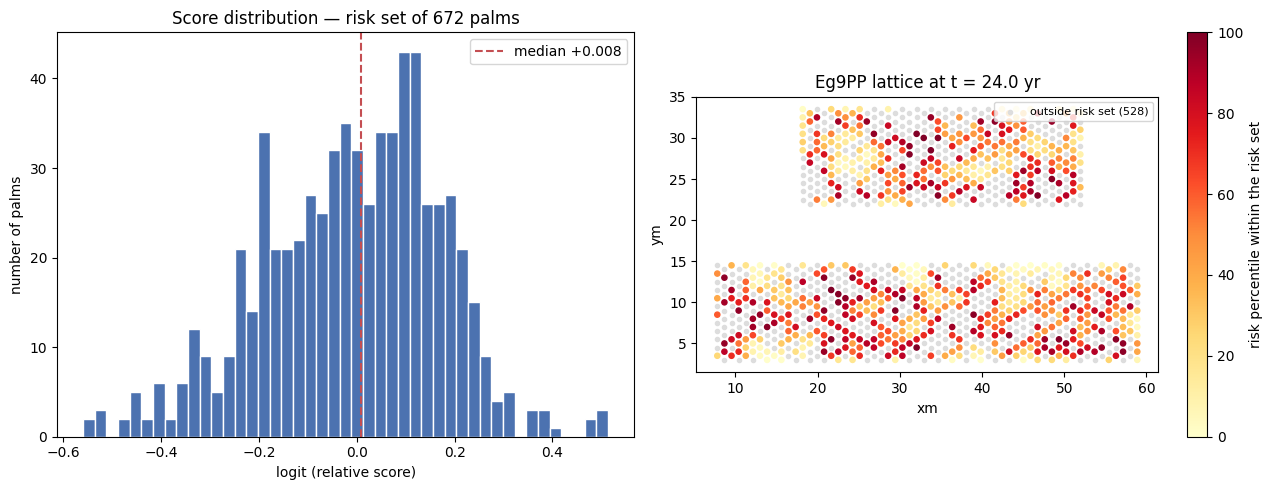

The two parcels separate cleanly along Y — that is what produces 0 cross-parcel
edges, and that is what makes leave-one-parcel-out a valid block-CV.


In [39]:
import matplotlib.pyplot as plt

xy = nodes[["xm", "ym"]].to_numpy()
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].hist(logits, bins=45, color="#4C72B0", edgecolor="white")
ax[0].axvline(np.median(logits), color="#C44E52", ls="--", label=f"median {np.median(logits):+.3f}")
ax[0].set_xlabel("logit (relative score)"); ax[0].set_ylabel("number of palms")
ax[0].set_title(f"Score distribution — risk set of {len(tr2)} palms"); ax[0].legend()

out_of_risk = np.isnan(pct)
ax[1].scatter(xy[out_of_risk, 0], xy[out_of_risk, 1], s=9, c="#DDDDDD",
              label=f"outside risk set ({int(out_of_risk.sum())})")
sc = ax[1].scatter(xy[~out_of_risk, 0], xy[~out_of_risk, 1], s=14,
                   c=pct[~out_of_risk], cmap="YlOrRd", vmin=0, vmax=100)
plt.colorbar(sc, ax=ax[1], label="risk percentile within the risk set")
ax[1].set_aspect("equal"); ax[1].set_xlabel("xm"); ax[1].set_ylabel("ym")
ax[1].set_title(f"Eg9PP lattice at t = {pr['census_t']:.1f} yr"); ax[1].legend(loc="upper right", fontsize=8)

plt.tight_layout(); plt.show()
print("The two parcels separate cleanly along Y — that is what produces 0 cross-parcel")
print("edges, and that is what makes leave-one-parcel-out a valid block-CV.")

In [40]:
ids = np.asarray(ck["data"]["palm_ids"])
top = tr2[np.argsort(-logits)][:10]
print("Top 10 palms by risk rank — RELATIVE SCORE, not a probability\n")
print(f"{'#':>3} {'palm_id':>10} {'parcel':>7} {'logit':>9} {'percentile':>11} {'sick neighbours':>17}")
nb_sick = (A @ np.isin(st[t_star], ("S", "D")).astype(float))
for r_, i in enumerate(top, 1):
    print(f"{r_:>3} {ids[i]:>10} {nodes.parcel.iloc[i]:>7} {full[i]:>+9.4f} "
          f"{pct[i]:>10.1f}% {int(nb_sick[i]):>14}/{int(A[i].sum())}")

sel = tr2[np.argsort(-logits)]
print(f"\nmean sick neighbours — top 10: {nb_sick[sel[:10]].mean():.2f}"
      f" | whole risk set: {nb_sick[tr2].mean():.2f}"
      f" | bottom 10: {nb_sick[sel[-10:]].mean():.2f}")
print("Descriptive only — computed on the model's own training data, so it is not")
print("evidence of performance. It does show the model is using neighbour pressure.")

Top 10 palms by risk rank — RELATIVE SCORE, not a probability

  #    palm_id  parcel     logit  percentile   sick neighbours
  1    D2L3_54     44B   +0.5140      100.0%              4/6
  2    D2L3_55     44B   +0.5111       99.9%              4/6
  3     D2L3_6     44A   +0.5087       99.7%              5/6
  4    D2L3_51     44B   +0.4796       99.6%              5/6
  5    D2L3_71     44B   +0.4718       99.4%              4/6
  6    D2L3_26     44A   +0.4162       99.3%              4/6
  7    D2L3_60     44B   +0.3832       99.1%              3/6
  8    D5L2_20     44A   +0.3782       99.0%              4/6
  9    D2L3_46     44B   +0.3769       98.8%              4/6
 10     D2L3_9     44A   +0.3703       98.7%              3/6

mean sick neighbours — top 10: 4.00 | whole risk set: 1.97 | bottom 10: 0.40
Descriptive only — computed on the model's own training data, so it is not
evidence of performance. It does show the model is using neighbour pressure.


## §10 — The formal check (separate process)

Everything above ran **inside** this notebook, which has already imported `dataset.py` and `models_real.py`. That does not yet prove the checkpoint stands on its own.

`verify_checkpoint.py` runs the same five checks in **its own Python process**, and deliberately does **not** import `train_final.py` or `run_real.py`. If it passes, a downstream demo needs only: `stgnn_final.pt` + `data_clean/*.csv` + `dataset.py` + `models_real.py`.

In [ ]:
r = subprocess.run([sys.executable, "verify_checkpoint.py"], cwd=HERE,
                   capture_output=True, text=True, encoding="utf-8", errors="replace")
print(r.stdout)
if r.stderr.strip():
    print("--- stderr ---\n", r.stderr)
print("exit code:", r.returncode, "   (0 = all checks passed)")


V1 — FILE LOADS
  file     : c:\Users\Rifqi\Documents\Datathon\oil-palm-detection-datathon-2026\layer2_real\stgnn_final.pt (60.4 KB)
  [OK  ] required fields present — 9 fields present
  class    : STGNN | arch {'in_dim': 24, 'hidden': 34, 'n_rel': 1}
  task     : h=3 window=3 risk_status=A pos=['S', 'D']
  training : fold=NONE -- all 1,200 palms, both parcels
             40828 examples, 1915 positives (4.69%), 60 epochs, seed 0

V2 — ARCHITECTURE MATCHES models_real.py AS IT IS TODAY
  [OK  ] hidden matches — checkpoint 34 vs models_real.HIDDEN 34
  [OK  ] n_rel matches — checkpoint 1 vs models_real.N_REL 1
  [OK  ] load_state_dict(strict=True) — missing=[] unexpected=[]
  [OK  ] parameter count matches — 8875 == 8875

V3 — FROZEN DATA HAS NOT SHIFTED (recomputed from CSV)
  [OK  ] feature shape — (45, 1200, 24)
  [OK  ] feature tensor sha256 — 70ef7eb522284fd7... vs 70ef7eb522284fd7...
  [OK  ] adjacency sha256 — 1ed21d8948b3f65a... vs 1ed21d8948b3f65a...
  [OK  ] feature column na

: 

## Summary

| | |
|---|---|
| **Artifact** | `layer2_real/stgnn_final.pt` — 60.4 KB |
| **Architecture** | `STGNN`, 8,875 parameters, `in_dim=24 hidden=34 n_rel=1` |
| **Trained on** | 40,828 examples · 1,915 positives (4.69%) · all 1,200 palms, **no fold** |
| **Task** | h=3 censuses, WINDOW=3, risk set = status `A` |
| **Inference input** | `F_seq (672, 3, 24)` · `D_seq (672, 3, 1, 24)` |
| **Output** | `logits (672,)` float32 — one relative score per palm in the risk set |
| **On the full lattice** | a `(1200,)` vector with 528 NaN (outside the risk set) |

### Closed

**DoD #4** — the checkpoint saves, reloads in a separate process, and runs one forward pass. The reload is proven **faithful**, not merely error-free: probe logits reproduce to within ~3e-08.

### Still open

**DoD #5** — a ranked CSV and quantile risk map as formal artifacts. The plot in §9 is only a notebook diagnostic. This checkpoint is the input that step needs.

### What must be restated every time this artifact is used

1. No performance number may be quoted from it — it has no held-out set. Performance numbers come only from `run_real.py` / `run_v2.py`.
2. Its output is a ranking, not a probability. Never present `sigmoid(logit)` as a percentage.
3. The model was trained on a **breeding-trial** plantation (Eg9PP, 2 parcels), not a production estate. The effect size differs by up to 2.6× between blocks.